# ペダルを守れ！自転車盗難ハッカソン

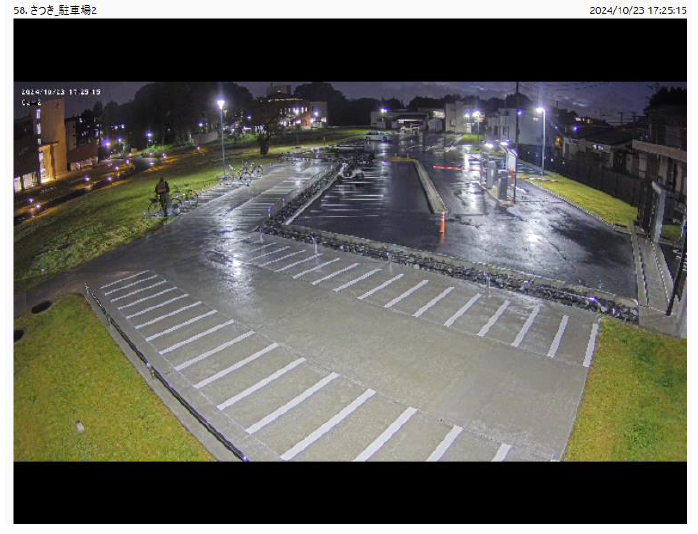

千葉市内で発生した自転車盗難事件のデータを分析し、重要なパターンを見つけ出し、防止策を提案してください。本ハッカソンは、データ分析スキルとデータビジュアライゼーションスキルを磨くことを目的としています。

## 目標
1. 自転車盗難の発生パターンを特定する。
2. データを視覚化して洞察を深める。
3. 効果的な防止策を提案する。

## データのインポート

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# set font
import matplotlib as mpl

# for PC
mpl.rc('font',family='MS Gothic')

# for Mac
mpl.rc('font',family='Hiragino Maru Gothic Pro')

# データの読み込み
df = pd.read_csv('chibike.csv', encoding='utf-8')

In [ ]:
_df_head = df.head()
_df_head


## チャレンジ内容

### 1. 基本的な集計 (カウント)
1. 盗難事件の総数を計算する。
2. ロック状況（施錠した vs 施錠せず）ごとの盗難数を算出する。
3. 地域別（市区町村）、時間別の盗難数を集計する。

In [ ]:
# 基本的な集計




### 2. ランキング
1. 最も盗難が多い上位5つの町丁目（発生地）を特定する。
2. 発生時間（始期）ごとの上位5つの時間帯を特定する。
3. 被害者の年齢グループごとの上位5つを特定する。

In [ ]:
# ランキング
top_blocks = df['町丁目（発生地）'].value_counts().head(5)
top_hours = df['発生時（始期）'].value_counts().sort_values(ascending=False).head(5)
top_age = df['被害者の年齢'].value_counts().head(5)

print('盗難が多い町丁目 Top5:\n', top_blocks)
print('\n発生時間 Top5:\n', top_hours)
print('\n被害者年齢グループ Top5:\n', top_age)


### 3. 基本的なチャート
1. 月ごとの盗難数をバーグラフで表示する。
2. ロック状況（施錠した vs 施錠せず）の割合を円グラフで表示する。

In [ ]:
# 基本チャート
df['発生年月日（始期）'] = pd.to_datetime(df['発生年月日（始期）'].astype(str), errors='coerce')
df['month'] = df['発生年月日（始期）'].dt.to_period('M')
monthly = df['month'].value_counts().sort_index()
lock_counts = df['施錠関係'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(12,4))
monthly.plot(kind='bar', ax=axes[0], color='skyblue')
axes[0].set_title('月別盗難件数')
axes[0].set_xlabel('month')
axes[0].set_ylabel('件数')

axes[1].pie(lock_counts, labels=lock_counts.index, autopct='%1.1f%%', startangle=90)
axes[1].set_title('施錠状況の割合')
plt.tight_layout()
plt.show()


### 4. 高度なチャート
1. 時間ごとの盗難数をバーグラフで表示する。
2. 時間帯ごとのロック状況（施錠した vs 施錠せず）をスタックバーグラフで表示する。

In [ ]:
# 高度なチャート
hour_series = pd.to_numeric(df['発生時（始期）'], errors='coerce')
hour_counts = hour_series.value_counts().sort_index()
lock_by_hour = df.assign(発生時_num=hour_series).pivot_table(
    index='発生時_num', columns='施錠関係', values='罪名', aggfunc='count', fill_value=0
)
lock_by_hour = lock_by_hour.sort_index()

fig, axes = plt.subplots(1, 2, figsize=(12,4))
hour_counts.plot(kind='bar', ax=axes[0], color='coral')
axes[0].set_title('時間ごとの盗難件数')
axes[0].set_xlabel('時間')
axes[0].set_ylabel('件数')

lock_by_hour.plot(kind='bar', stacked=True, ax=axes[1])
axes[1].set_title('時間×施錠状況')
axes[1].set_xlabel('時間')
axes[1].set_ylabel('件数')
plt.tight_layout()
plt.show()


### 5. マップ
1. foliumを使ってマップを作れ！
1. MarkerClusterを使ってよりよいマップを

In [ ]:
# マップ (シンプルなマーカークラスタ)
import folium
from folium.plugins import MarkerCluster

# 千葉市付近をベースにしたシンプルなマップ
base_loc = (35.607, 140.106)
m = folium.Map(location=base_loc, zoom_start=10)
cluster = MarkerCluster().add_to(m)

# 位置情報がないので、行番号を使って少しずつずらしながら配置
for i, row in df.reset_index().iterrows():
    lat = base_loc[0] + 0.01 * ((i % 10) - 5) / 10
    lon = base_loc[1] + 0.01 * ((i // 10 % 10) - 5) / 10
    tip = f"{row['市区町村（発生地）']} {row['町丁目（発生地）']} / {row['施錠関係']}"
    folium.Marker(location=(lat, lon), tooltip=tip).add_to(cluster)

m
